In [88]:
import pandas as pd

hydrazide_df = pd.read_csv("../data/hydrazide_library.csv")
len(hydrazide_df)

10000

In [89]:
from rdkit import Chem

# Convert SMILES to RDKit molecules
hydrazide_df["mol"] = hydrazide_df["SMILES"].apply(Chem.MolFromSmiles)

# Count invalid molecules
invalid_count = hydrazide_df["mol"].isna().sum()
print(f"Invalid SMILES: {invalid_count}")

# Show invalid molecules (optional)
invalid_smiles = hydrazide_df[hydrazide_df["mol"].isna()]
display(invalid_smiles[["Name", "SMILES"]])

# Remove invalid molecules
hydrazide_df = hydrazide_df[
    hydrazide_df["mol"].notna()
].reset_index(drop=True)

print(f"Remaining molecules: {len(hydrazide_df)}")

Invalid SMILES: 11


,Name,SMILES
7700,5-[1-(3-Chloro-2-pyridinyl)-3-(trifluoromethyl...,C1=CC=C2C(=C1)C=C(C3=C2OBr=C(N3)C4=CC(=NN4C5=C...
7701,5-[1-(3-Chloro-2-pyridinyl)-3-(trifluoromethyl...,C1=CC=C2C(=C1)C=C(C3=C2OCl=C(N3)C4=CC(=NN4C5=C...
7702,4-[1-(3-Chloro-2-pyridinyl)-3-(trifluoromethyl...,CC1=CC(=C2C(=C1)OBr=C(N2)C3=CC(=NN3C4=C(C=CC=N...
8340,CID 157315559,[HH].B(Br)(Br)Br.CCO.CC#N.CC1=CN=C(C=C1)Br.CC1...
8405,2-(4-aminochloranuidylpiperidin-1-yl)-5-(4-chl...,CC1CCNCC1.CC1CCN(CC1)C2=NN=C(O2)C3=CC=C(C=C3)C...
8490,sodium;tert-butyl 2-bromoacetate;4-O-tert-buty...,[HH].[H-].[2H]CF.C.C.[CH3-].CCNC(=O)CCCC(C)C.C...
8525,"lithium;[1-[1-[2,4-bis(trifluoromethyl)phenyl]...",[Li+].CCOC(=O)C1=NN=C(O1)C2=CC=CC=N2.CCOC(=O)C...
8661,"benzoic acid;3-(5-butyl-1,3,4-oxadiazol-2-yl)-...",CCCCC1=NN=C(O1)C2=CC(=CC=C2)S(=O)(=O)NC3=CC=CC...
8810,"1-aminochloranuidyl-1-methoxy-2,2-dimethylprop...",C.CCC(=O)CC(C)(C)C.CC1=CC=C(C=C1)C(C)(C)C.CC(C...
8870,"lithium;[1-[1-[2,4-bis(trifluoromethyl)phenyl]...",[Li+].C.C.C.C.C.C.C.C.C.C.CCOC(=O)C1=NN=C(O1)C...


Remaining molecules: 9989


In [90]:
hydrazide_pattern = Chem.MolFromSmarts("C(=O)NN")

true_hydrazide_df = hydrazide_df[
    hydrazide_df["mol"].apply(
        lambda mol: mol.HasSubstructMatch(hydrazide_pattern)
    )
].reset_index(drop=True)

print(f"Remaining hydrazides: {len(true_hydrazide_df)}")

Remaining hydrazides: 9978


In [91]:
neutral_hydrazide_df = true_hydrazide_df[
    true_hydrazide_df["mol"].apply(
        lambda mol: Chem.GetFormalCharge(mol) == 0
    )
].reset_index(drop=True)

print(len(neutral_hydrazide_df))

9843


In [109]:
from rdkit.Chem import rdMolDescriptors

neutral_hydrazide_df["Aromatic_Ring_Count"] = hydrazide_df["mol"].apply(
    rdMolDescriptors.CalcNumAromaticRings
)
neutral_hydrazide_df["Aromatic_Ring_Count"].head()

0    1
1    0
2    0
3    1
4    0
Name: Aromatic_Ring_Count, dtype: int64

In [93]:
filtered_hydrazide_df = neutral_hydrazide_df[
    (neutral_hydrazide_df["Molecular_Weight"] < 500) &
    (neutral_hydrazide_df["XLogP"] < 5) &
    (neutral_hydrazide_df["Polar_Area"] < 140) &
    (neutral_hydrazide_df["Rotatable_Bond_Count"] < 10) &
    (neutral_hydrazide_df["Aromatic_Ring_Count"] >= 1)
].reset_index(drop=True)

print(len(filtered_hydrazide_df))

6437


In [124]:
functional_groups = {
    # Nitrogen heterocycles
    "Pyridine": Chem.MolFromSmarts("n1ccccc1"),
    "Pyrrole": Chem.MolFromSmarts("[nH]1cccc1"),
    "Imidazole": Chem.MolFromSmarts("c1ncc[nH]1"),
    "Pyrazole": Chem.MolFromSmarts("c1n[nH]cc1"),
    "1,2,3-Triazole": Chem.MolFromSmarts("n1nncc1"),
    "1,2,4-Triazole": Chem.MolFromSmarts("n1ncnc1"),
    "1,2,3,4-Tetrazole": Chem.MolFromSmarts("c1nnnn1"),
    "1-H-Tetrazole": Chem.MolFromSmarts("[nH]1nnnc1"),
    "Quinoline": Chem.MolFromSmarts("c1ccc2ncccc2c1"),
    "Isoquinoline": Chem.MolFromSmarts("c1ccc2ccnc2c1"),

    # Oxygen/Sulfur heterocycles
    "Thiophene": Chem.MolFromSmarts("c1ccsc1"),
    "Furan": Chem.MolFromSmarts("c1ccoc1"),
    "Benzofuran": Chem.MolFromSmarts("c1ccc2occc2c1"),

    # Functional groups
    "Phenol": Chem.MolFromSmarts("c[OH]"),
    "Methoxy": Chem.MolFromSmarts("[OX2][CH3]"),
    "Nitro": Chem.MolFromSmarts("[N+](=O)[O-]"),
    "Cyano": Chem.MolFromSmarts("C#N"),

    # Halogens
    "Fluoro": Chem.MolFromSmarts("[F]"),
    "Chloro": Chem.MolFromSmarts("[Cl]"),
    "Bromo": Chem.MolFromSmarts("[Br]"),
    "Iodo": Chem.MolFromSmarts("[I]"),

    # Carbonyl derivatives
    "Carboxylic_Acid": Chem.MolFromSmarts("C(=O)[OH]"),
    "Ester": Chem.MolFromSmarts("C(=O)O[#6]"),
    "Aldehyde": Chem.MolFromSmarts("[CX3H](=O)"),
    "Ketone": Chem.MolFromSmarts("[#6][CX3](=O)[#6]"),

    # Sulfur groups
    "Sulfone": Chem.MolFromSmarts("S(=O)(=O)"),
    "Sulfonamide": Chem.MolFromSmarts("S(=O)(=O)N"),

    # Medicinal chemistry
    "Trifluoromethyl": Chem.MolFromSmarts("C(F)(F)F")
}

for name, pattern in functional_groups.items():
    filtered_hydrazide_df[name] = filtered_hydrazide_df["mol"].apply(
        lambda mol: mol.HasSubstructMatch(pattern)
    )

fg_counts = filtered_hydrazide_df[
    functional_groups.keys()
].sum().sort_values(ascending=False)

display(fg_counts)

Fluoro               3521
Pyridine             1272
Trifluoromethyl      1219
Chloro               1020
Methoxy               525
Sulfone               350
Quinoline             276
Isoquinoline          263
Bromo                 249
Sulfonamide           239
Ester                 230
Phenol                192
Thiophene             181
Pyrrole               169
Ketone                149
Furan                 147
Cyano                 110
1,2,4-Triazole        106
Nitro                 106
Carboxylic_Acid        98
Pyrazole               94
Imidazole              70
Iodo                   58
1,2,3-Triazole         47
Benzofuran             34
1,2,3,4-Tetrazole      34
Aldehyde               31
1-H-Tetrazole           0
dtype: int64

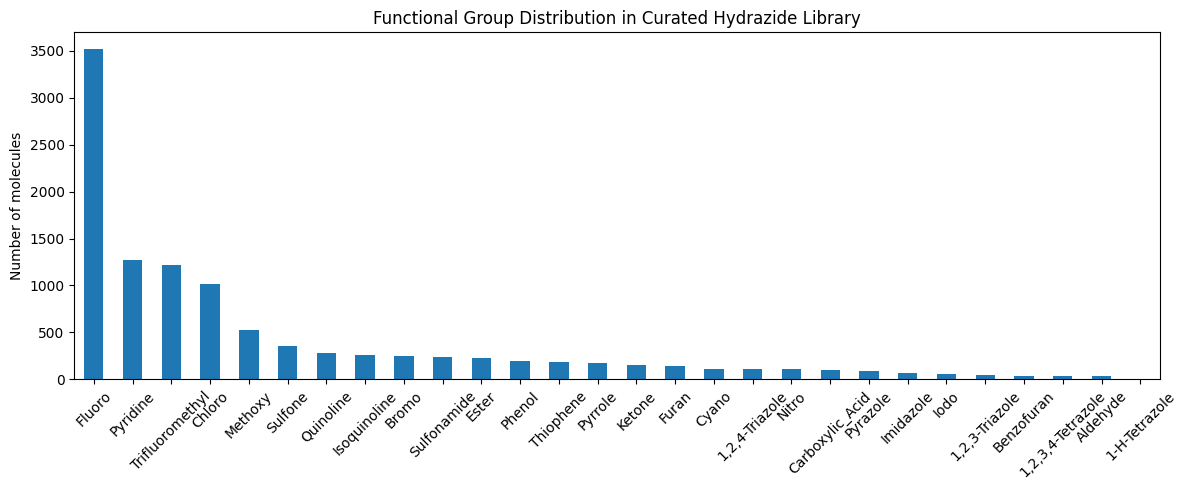

In [125]:
import matplotlib.pyplot as plt

fg_counts.plot.bar(figsize=(12,5))

plt.ylabel("Number of molecules")
plt.title("Functional Group Distribution in Curated Hydrazide Library")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [126]:
hydrazide = Chem.MolFromSmarts("[CX3](=O)[NH][NH2]")
filtered_hydrazide_df["Hydrazide_Count"] = filtered_hydrazide_df["mol"].apply(
    lambda m: len(m.GetSubstructMatches(hydrazide))
)

filtered_hydrazide_df["Hydrazide_Count"].value_counts().sort_index()

Hydrazide_Count
1    5919
2      52
Name: count, dtype: int64

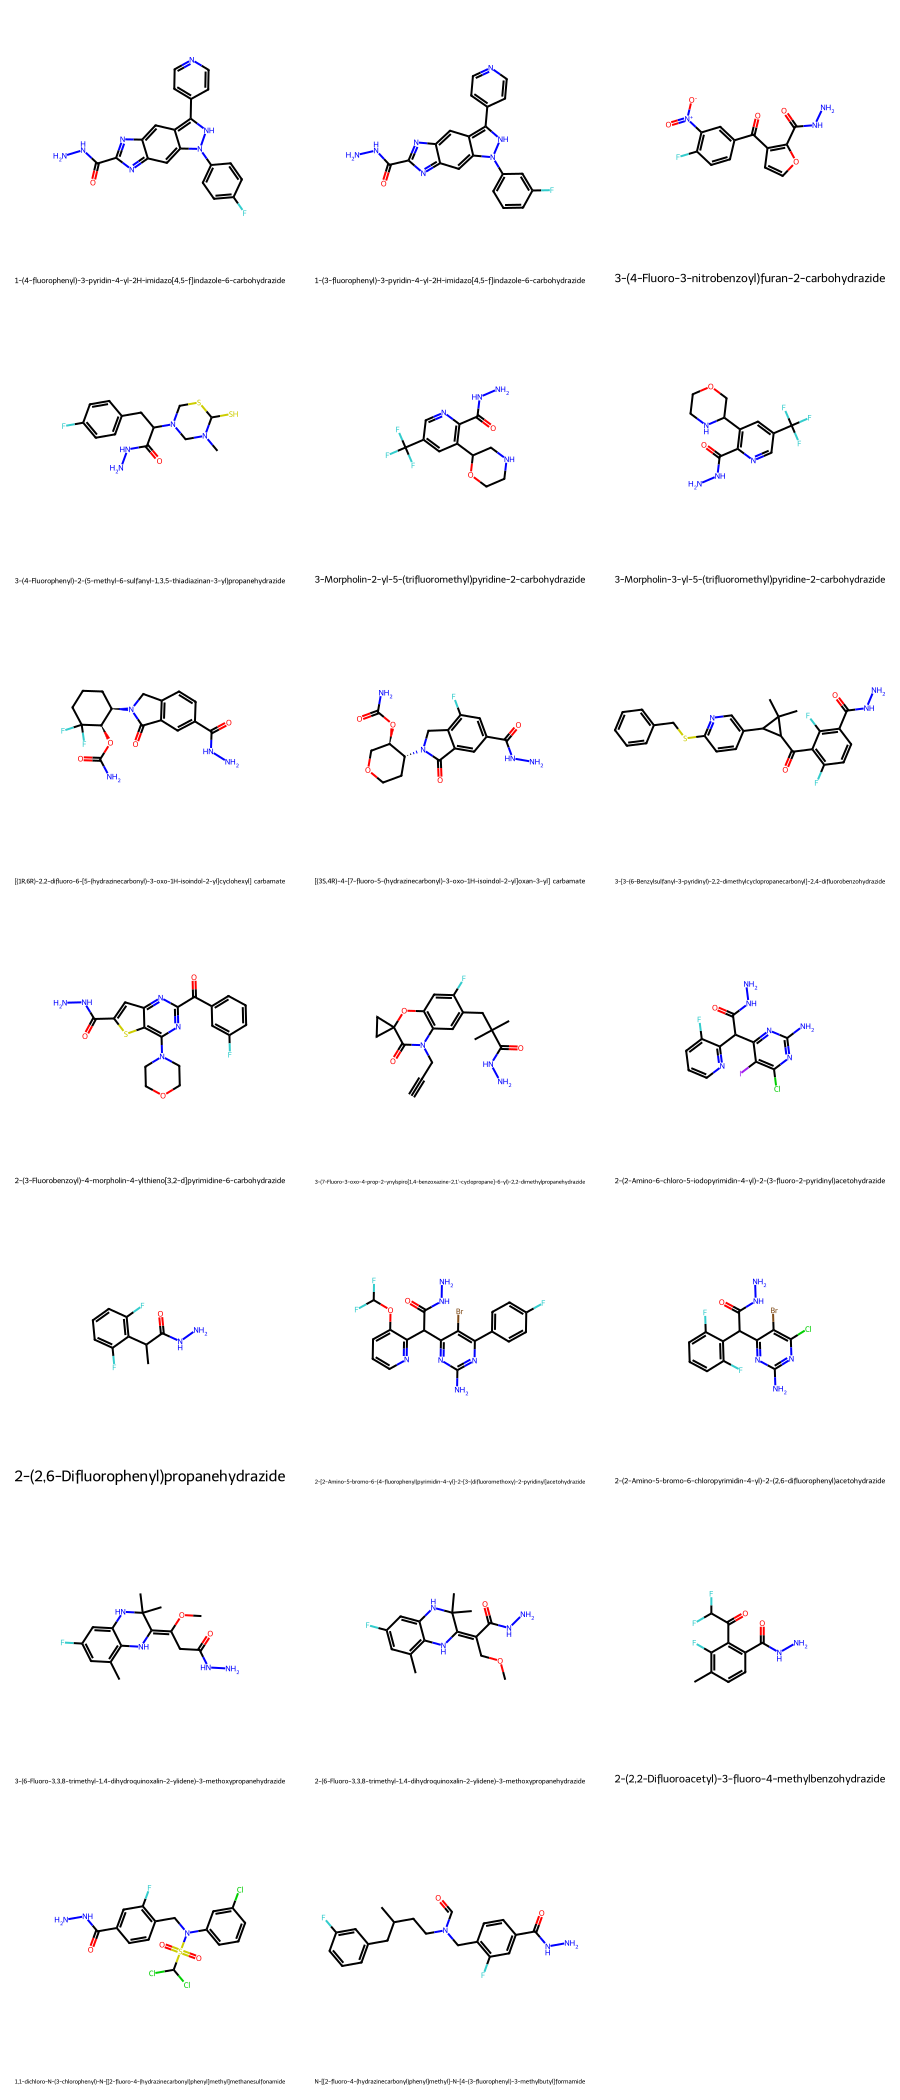

In [120]:
from rdkit.Chem import Draw

mols_2 = filtered_hydrazide_df[
    filtered_hydrazide_df["Hydrazide_Count"] == 1
]["mol"].tail(20).tolist()

legends_2 = filtered_hydrazide_df[
    filtered_hydrazide_df["Hydrazide_Count"] == 1
]["Name"].astype(str).tail(20).tolist()

Draw.MolsToGridImage(
    mols_2,
    legends=legends_2,
    molsPerRow=3,
    subImgSize=(300,300)
)

In [121]:
hydrazide = Chem.MolFromSmarts("[CX3](=O)[NH][NH2]")

filtered_hydrazide_df["Is_Hydrazide"] = filtered_hydrazide_df["mol"].apply(
    lambda m: m is not None and m.HasSubstructMatch(hydrazide)
)

filtered_hydrazide_df["Is_Hydrazide"].value_counts()

Is_Hydrazide
True    5971
Name: count, dtype: int64

In [122]:
def has_aromatic_ring(mol):
    return any(atom.GetIsAromatic() for atom in mol.GetAtoms())

filtered_hydrazide_df["Aromatic"] = filtered_hydrazide_df["mol"].apply(has_aromatic_ring)

filtered_hydrazide_df["Aromatic"].value_counts()

Aromatic
True    5971
Name: count, dtype: int64

In [123]:
def has_aromatic_ring(mol):
    ring_info = mol.GetRingInfo()
    for ring in ring_info.AtomRings():
        if all(mol.GetAtomWithIdx(i).GetIsAromatic() for i in ring):
            return True
    return False

filtered_hydrazide_df = filtered_hydrazide_df[
    filtered_hydrazide_df["mol"].apply(has_aromatic_ring)
].copy()

len(filtered_hydrazide_df)

5971

In [133]:
filtered_hydrazide_df.to_csv(
    "../data/clean_hydrazides.csv",
    index=False
)